# Capstone Project — Breast Cancer Diagnosis Classifier
### Week 12: End-to-End ML Pipeline (Data → Cleaning → EDA → Modeling → Evaluation → Deployment)

**Problem statement:** Given a set of measurements taken from a cell nucleus image
(radius, texture, smoothness, concavity, etc.), predict whether a breast mass is
**malignant** or **benign**. This is a binary classification problem using the
classic **Breast Cancer Wisconsin (Diagnostic)** dataset (569 samples, 30 numeric
features), bundled with scikit-learn.

**Why this problem:** it's a real, well-scoped, well-documented dataset that
supports a genuinely complete pipeline — meaningful EDA, several comparable model
types, real evaluation trade-offs (precision vs. recall matter a lot in a medical
context), and a natural, demoable deployment step — while staying small enough to
build and explain within the time available.

> **Disclaimer:** this is a learning exercise on a public benchmark dataset, not a
> real diagnostic tool. It is not medically validated and should never be used for
> actual clinical decisions.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, auc, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)


## 2. Load the data

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = np.where(data.target == 1, 'benign', 'malignant')

print("Shape:", df.shape)
df.head()


Shape: (569, 31)


   mean radius  mean texture  ...  worst fractal dimension  diagnosis
0        17.99         10.38  ...                  0.11890  malignant
1        20.57         17.77  ...                  0.08902  malignant
2        19.69         21.25  ...                  0.08758  malignant
3        11.42         20.38  ...                  0.17300  malignant
4        20.29         14.34  ...                  0.07678  malignant

[5 rows x 31 columns]

## 3. Data cleaning check
Even with a curated dataset, this step should never be skipped — check for
missing values, duplicate rows, and sensible data types before doing anything else.

In [3]:
print("Missing values total:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes.value_counts())
print("\nClass balance:\n", df['diagnosis'].value_counts())


Missing values total: 0
Duplicate rows: 0

Data types:
 float64    30
str         1
Name: count, dtype: int64

Class balance:
 diagnosis
benign       357
malignant    212
Name: count, dtype: int64


**Findings:** no missing values, no duplicate rows, all numeric features — this dataset
is already clean. There **is** a mild class imbalance (357 benign vs. 212 malignant,
~63/37 split), which matters for evaluation: overall accuracy alone could look good
while still missing malignant cases, so precision/recall/F1 per class need checking,
not just accuracy.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Class balance

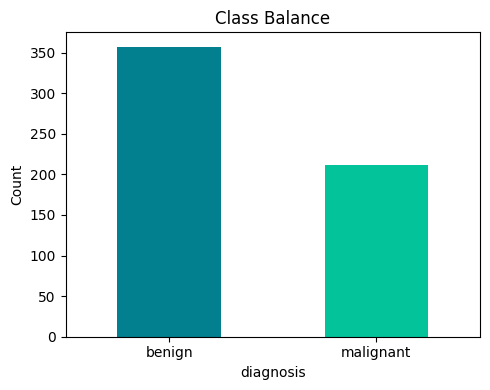

In [4]:
plt.figure(figsize=(5,4))
df['diagnosis'].value_counts().plot(kind='bar', color=['#028090','#02C39A'])
plt.title('Class Balance')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.2 Correlation between features
Using just the 'mean' features for readability (there are also 'error' and 'worst' versions of each).

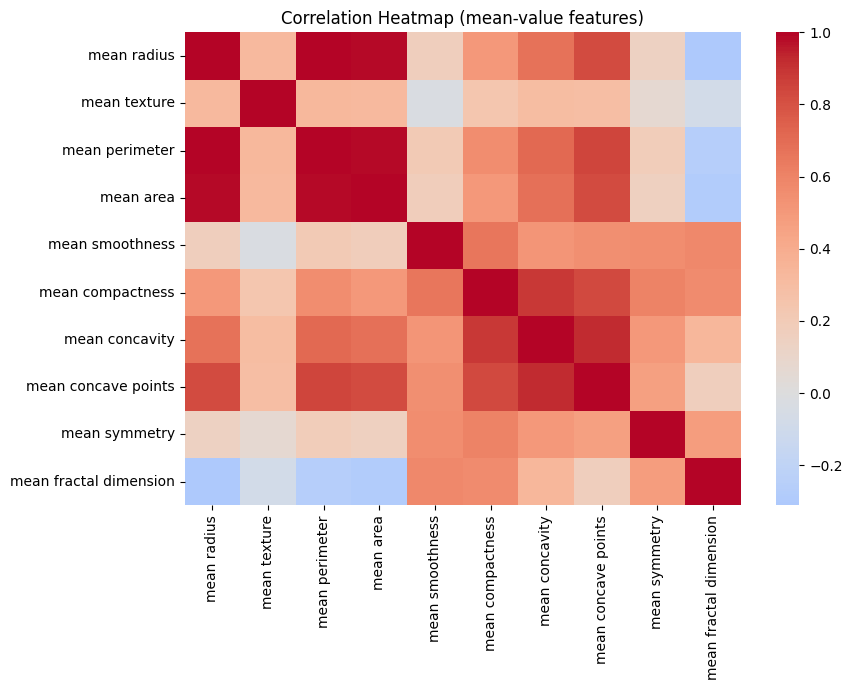

In [5]:
mean_cols = [c for c in df.columns if c.startswith('mean')]
plt.figure(figsize=(9,7))
sns.heatmap(df[mean_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (mean-value features)')
plt.tight_layout()
plt.show()


**Observation:** several size-related features (radius, perimeter, area) are highly
correlated with each other, as expected geometrically. This is useful context for
interpreting model coefficients later — correlated features can "share" importance.

### 4.3 Feature distributions by diagnosis
Do malignant and benign cases actually look different on key features?

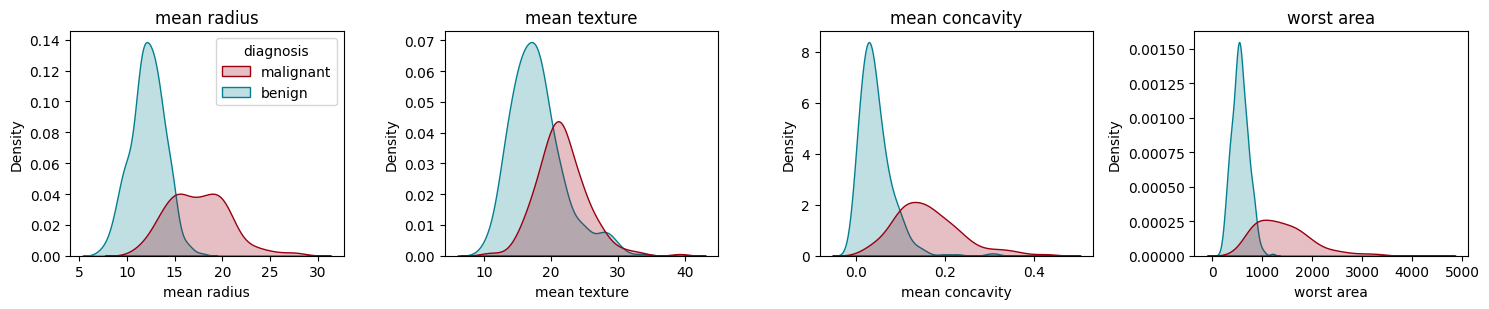

In [6]:
key_feats = ['mean radius', 'mean texture', 'mean concavity', 'worst area']
fig, axes = plt.subplots(1, 4, figsize=(15,3.2))
for ax, feat in zip(axes, key_feats):
    sns.kdeplot(data=df, x=feat, hue='diagnosis', fill=True, ax=ax,
                palette=['#990011','#028090'], legend=(feat==key_feats[0]))
    ax.set_title(feat)
plt.tight_layout()
plt.show()


**Observation:** malignant cases tend to have higher radius, texture, concavity, and
worst-area values — a reassuring sanity check that the features actually carry
predictive signal before we build any model.

## 5. Modeling
Three models are compared, spanning the range of typical beginner-to-intermediate
approaches: a simple linear model, a tree-based ensemble, and a small neural network.

In [7]:
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 455  Test size: 114


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

results_df = pd.DataFrame(results).T.round(4)
results_df


                      accuracy  precision  recall      f1  roc_auc
Logistic Regression     0.9825     0.9861  0.9861  0.9861   0.9954
Random Forest           0.9561     0.9589  0.9722  0.9655   0.9932
Neural Network (MLP)    0.9561     0.9855  0.9444  0.9645   0.9921

## 6. Evaluation
Accuracy alone isn't enough for a medical-style problem — precision, recall, F1 and
ROC-AUC all matter, especially recall on the malignant class (missing a real
malignant case is worse than a false alarm).

### 6.1 ROC curves — all three models

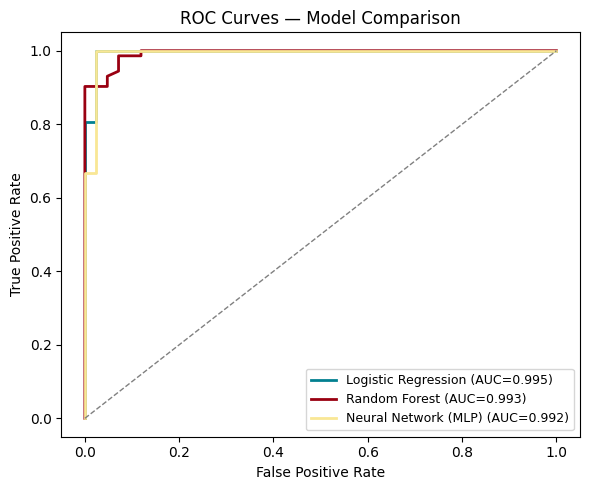

In [9]:
plt.figure(figsize=(6,5))
colors = ['#028090', '#990011', '#F9E795']
for (name, model), color in zip(models.items(), colors):
    y_proba = model.predict_proba(X_test_s)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=color, linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


### 6.2 Picking a final model
Logistic Regression comes out on top on F1 and is tied for the best ROC-AUC — and it's the simplest, most interpretable of the three. That combination makes it the right choice here, not just the best score.

In [10]:
best_name = max(results, key=lambda k: results[k]['f1'])
print("Best model by F1:", best_name)
print(results_df.loc[best_name])


Best model by F1: Logistic Regression
accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
Name: Logistic Regression, dtype: float64


### 6.3 Confusion matrix for the final model

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



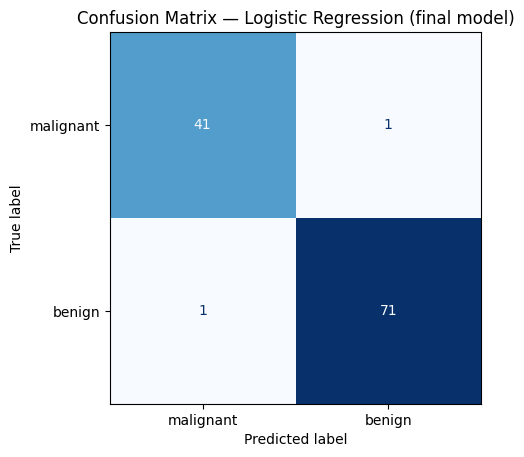

In [11]:
final_model = models["Logistic Regression"]
y_pred_final = final_model.predict(X_test_s)

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['malignant','benign'])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Logistic Regression (final model)")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_final, target_names=['malignant','benign']))


### 6.4 Which features drive the prediction?
Logistic Regression coefficients (on standardized features) double as a simple interpretability tool.

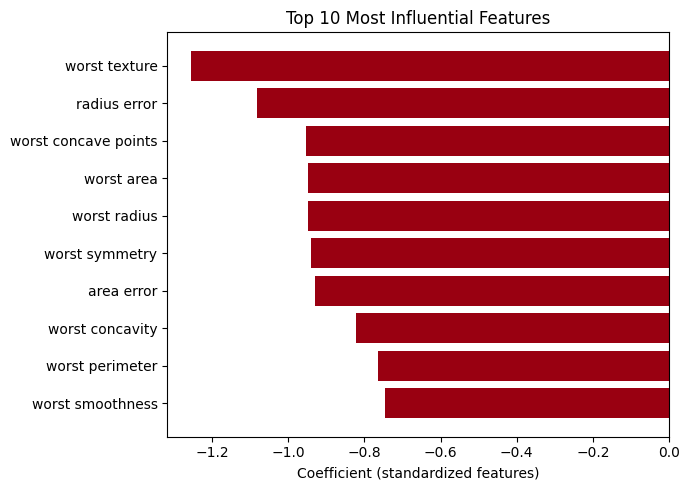

In [12]:
coefs = final_model.coef_[0]
idx = np.argsort(np.abs(coefs))[::-1][:10]
names = np.array(data.feature_names)[idx]
vals = coefs[idx]

plt.figure(figsize=(7,5))
colors2 = ['#990011' if v < 0 else '#028090' for v in vals]
plt.barh(names[::-1], vals[::-1], color=colors2[::-1])
plt.xlabel('Coefficient (standardized features)')
plt.title('Top 10 Most Influential Features')
plt.tight_layout()
plt.show()


**Note:** a positive coefficient here pushes toward the 'benign' class (since benign=1 was the positive label); a negative coefficient pushes toward 'malignant'.

## 7. Deployment (simplified)
The full model uses all 30 features, which isn't practical for a demo input form.
For deployment, a **second, simplified model using just the top 8 most influential
features** was trained, so a user only has to enter 8 numbers instead of 30. This
is a genuine real-world deployment trade-off — usability vs. using every available
signal — documented here rather than hidden.

In [13]:
top8_idx = idx[:8]
top8_names = np.array(data.feature_names)[top8_idx]
X_top8 = X[:, top8_idx]

X_train8, X_test8, y_train8, y_test8 = train_test_split(
    X_top8, y, test_size=0.2, random_state=42, stratify=y
)
scaler8 = StandardScaler()
X_train8_s = scaler8.fit_transform(X_train8)
X_test8_s = scaler8.transform(X_test8)

demo_model = LogisticRegression(max_iter=1000, random_state=42)
demo_model.fit(X_train8_s, y_train8)

demo_acc = accuracy_score(y_test8, demo_model.predict(X_test8_s))
demo_f1 = f1_score(y_test8, demo_model.predict(X_test8_s))
print(f"Full model (30 features):  accuracy={results['Logistic Regression']['accuracy']:.4f}  f1={results['Logistic Regression']['f1']:.4f}")
print(f"Demo model (8 features):   accuracy={demo_acc:.4f}  f1={demo_f1:.4f}")
print("\nTop 8 features used in the demo app:", list(top8_names))


Full model (30 features):  accuracy=0.9825  f1=0.9861
Demo model (8 features):   accuracy=0.9649  f1=0.9726

Top 8 features used in the demo app: [np.str_('worst texture'), np.str_('radius error'), np.str_('worst concave points'), np.str_('worst area'), np.str_('worst radius'), np.str_('worst symmetry'), np.str_('area error'), np.str_('worst concavity')]


The demo model trades a small amount of accuracy for a form a person can actually fill in. Both models and the scaler are exported with `pickle` and used by the Flask app in `/app` — see the project README for how to run it.

## 8. Results summary

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression (final, 30 feat.) | 0.9825 | 0.9861 | 0.9861 | 0.9861 | 0.9954 |
| Random Forest | 0.9561 | 0.9589 | 0.9722 | 0.9655 | 0.9932 |
| Neural Network (MLP) | 0.9561 | 0.9855 | 0.9444 | 0.9645 | 0.9921 |
| **Deployment demo model (8 feat.)** | 0.9649 | — | — | 0.9726 | — |

## 9. What I'd improve with more time

- **Get a second opinion on feature simplification.** Cutting to 8 features for the
  demo was based on coefficient magnitude alone — a mentor/domain expert review of
  which features are clinically meaningful (vs. just statistically convenient) would
  make that trade-off more defensible.
- **Handle the class imbalance more deliberately** — e.g. class weighting or
  resampling — rather than relying on stratified splitting alone, and specifically
  optimize/report the malignant-class recall as the headline metric, since missing
  a malignant case is the costliest kind of error here.
- **Add uncertainty/calibration checks** (e.g. a calibration curve) — a model used
  for anything diagnostic-adjacent should have predicted probabilities that actually
  mean what they say.
- **Harden the deployment app** — add input validation (range checks against
  realistic values), and swap the Flask dev server for a production WSGI server if
  this were ever exposed beyond a local demo.
- **Try feature engineering / dimensionality reduction (e.g. PCA)** as an explicit
  comparison point, rather than only comparing model *families* on the same raw
  features.
